In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("realistic_employee_attrition.csv")
df.head()

,Age,JobLevel,MonthlyIncome,YearsAtCompany,StockOptionLevel,DistanceFromHome,OverTime,WorkLifeBalance,JobSatisfaction,Attrition
0,44,4,13544.0,3,3,1,No,3,4,No
1,44,4,13296.0,3,3,21,No,4,4,No
2,32,3,8894.0,3,2,4,Yes,2,2,Yes
3,29,1,3442.0,0,0,2,No,4,4,No
4,52,5,20906.0,10,3,21,No,3,4,No


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Age               100000 non-null  int64  
 1   JobLevel          100000 non-null  int64  
 2   MonthlyIncome     100000 non-null  float64
 3   YearsAtCompany    100000 non-null  int64  
 4   StockOptionLevel  100000 non-null  int64  
 5   DistanceFromHome  100000 non-null  int64  
 6   OverTime          100000 non-null  object 
 7   WorkLifeBalance   100000 non-null  int64  
 8   JobSatisfaction   100000 non-null  int64  
 9   Attrition         100000 non-null  object 
dtypes: float64(1), int64(7), object(2)
memory usage: 7.6+ MB


In [4]:
df.duplicated().sum()

np.int64(22)

In [5]:
df.shape

(100000, 10)

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.shape

(99978, 10)

In [8]:
df.isna().sum()

Age                 0
JobLevel            0
MonthlyIncome       0
YearsAtCompany      0
StockOptionLevel    0
DistanceFromHome    0
OverTime            0
WorkLifeBalance     0
JobSatisfaction     0
Attrition           0
dtype: int64

In [9]:
df.columns.to_list()

['Age',
 'JobLevel',
 'MonthlyIncome',
 'YearsAtCompany',
 'StockOptionLevel',
 'DistanceFromHome',
 'OverTime',
 'WorkLifeBalance',
 'JobSatisfaction',
 'Attrition']

In [10]:
df.columns=df.columns.str.strip()

In [11]:

print(df["Attrition"].value_counts())
print(df["OverTime"].value_counts())

Attrition
No     49995
Yes    49983
Name: count, dtype: int64
OverTime
No     81771
Yes    18207
Name: count, dtype: int64


In [12]:
columns=["OverTime","Attrition"]
for col in columns:
    df[col]=df[col].replace({
        "Yes":1,
        "No":0
    })


C:\Users\intel\AppData\Local\Temp\ipykernel_5560\2103790927.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col]=df[col].replace({


In [13]:
df.head(20)

,Age,JobLevel,MonthlyIncome,YearsAtCompany,StockOptionLevel,DistanceFromHome,OverTime,WorkLifeBalance,JobSatisfaction,Attrition
0,44,4,13544.0,3,3,1,0,3,4,0
1,44,4,13296.0,3,3,21,0,4,4,0
2,32,3,8894.0,3,2,4,1,2,2,1
3,29,1,3442.0,0,0,2,0,4,4,0
4,52,5,20906.0,10,3,21,0,3,4,0
5,31,3,8376.0,1,2,5,0,4,3,0
6,30,4,13278.0,2,3,9,0,4,4,0
7,35,4,14803.0,7,3,14,0,4,4,0
8,31,4,13806.0,4,2,3,0,4,2,0
9,28,2,5332.0,0,1,8,0,4,4,0


In [14]:
max_values=pd.DataFrame({
    "MonthlyIncome":[df["MonthlyIncome"].max()],
    "DistanceFromHome":[df["DistanceFromHome"].max()],
    "WorkLifeBalance":[df["WorkLifeBalance"].max()]
})
max_values

,MonthlyIncome,DistanceFromHome,WorkLifeBalance
0,23636.0,29,4


In [15]:
from sklearn.preprocessing import StandardScaler

# Define the columns that have large continuous ranges
cols_to_scale = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'DistanceFromHome']

scaler = StandardScaler()

# Fit and transform the specific columns in your dataframe
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

In [16]:
correlation_matrix=df.corr()
correlation_matrix

,Age,JobLevel,MonthlyIncome,YearsAtCompany,StockOptionLevel,DistanceFromHome,OverTime,WorkLifeBalance,JobSatisfaction,Attrition
Age,1.000000,0.613622,0.633052,0.573472,0.532323,-0.000491,-0.044907,0.027552,0.387122,-0.417359
JobLevel,0.613622,1.000000,0.977658,0.579085,0.866505,-0.001557,-0.075681,0.046997,0.600792,-0.662040
MonthlyIncome,0.633052,0.977658,1.000000,0.656788,0.847209,-0.002847,-0.063451,0.039011,0.607552,-0.648226
YearsAtCompany,0.573472,0.579085,0.656788,1.000000,0.501900,-0.001047,-0.037734,0.022712,0.390920,-0.408707
StockOptionLevel,0.532323,0.866505,0.847209,0.501900,1.000000,-0.001938,-0.063826,0.038647,0.518654,-0.629241
DistanceFromHome,-0.000491,-0.001557,-0.002847,-0.001047,-0.001938,1.000000,0.044821,-0.029000,-0.014057,0.071039
OverTime,-0.044907,-0.075681,-0.063451,-0.037734,-0.063826,0.044821,1.000000,-0.671568,-0.301308,0.324250
WorkLifeBalance,0.027552,0.046997,0.039011,0.022712,0.038647,-0.029000,-0.671568,1.000000,0.427395,-0.375279
JobSatisfaction,0.387122,0.600792,0.607552,0.390920,0.518654,-0.014057,-0.301308,0.427395,1.000000,-0.758841
Attrition,-0.417359,-0.662040,-0.648226,-0.408707,-0.629241,0.071039,0.324250,-0.375279,-0.758841,1.000000


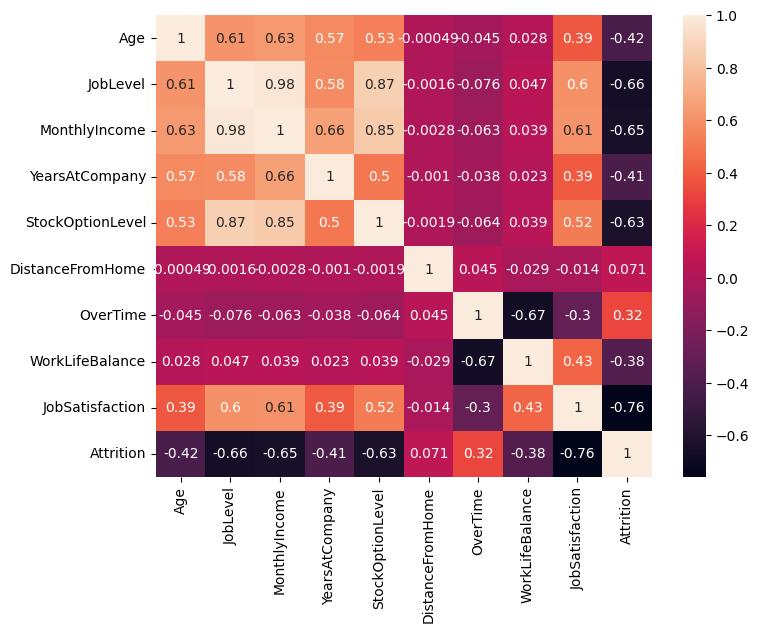

In [17]:
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix,annot=True)
plt.show()

C:\Users\intel\AppData\Local\Temp\ipykernel_5560\2206907014.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', ax=axes[0, 1], palette='Set2')
C:\Users\intel\AppData\Local\Temp\ipykernel_5560\2206907014.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y='DistanceFromHome', ax=axes[1, 1], palette='Set2')


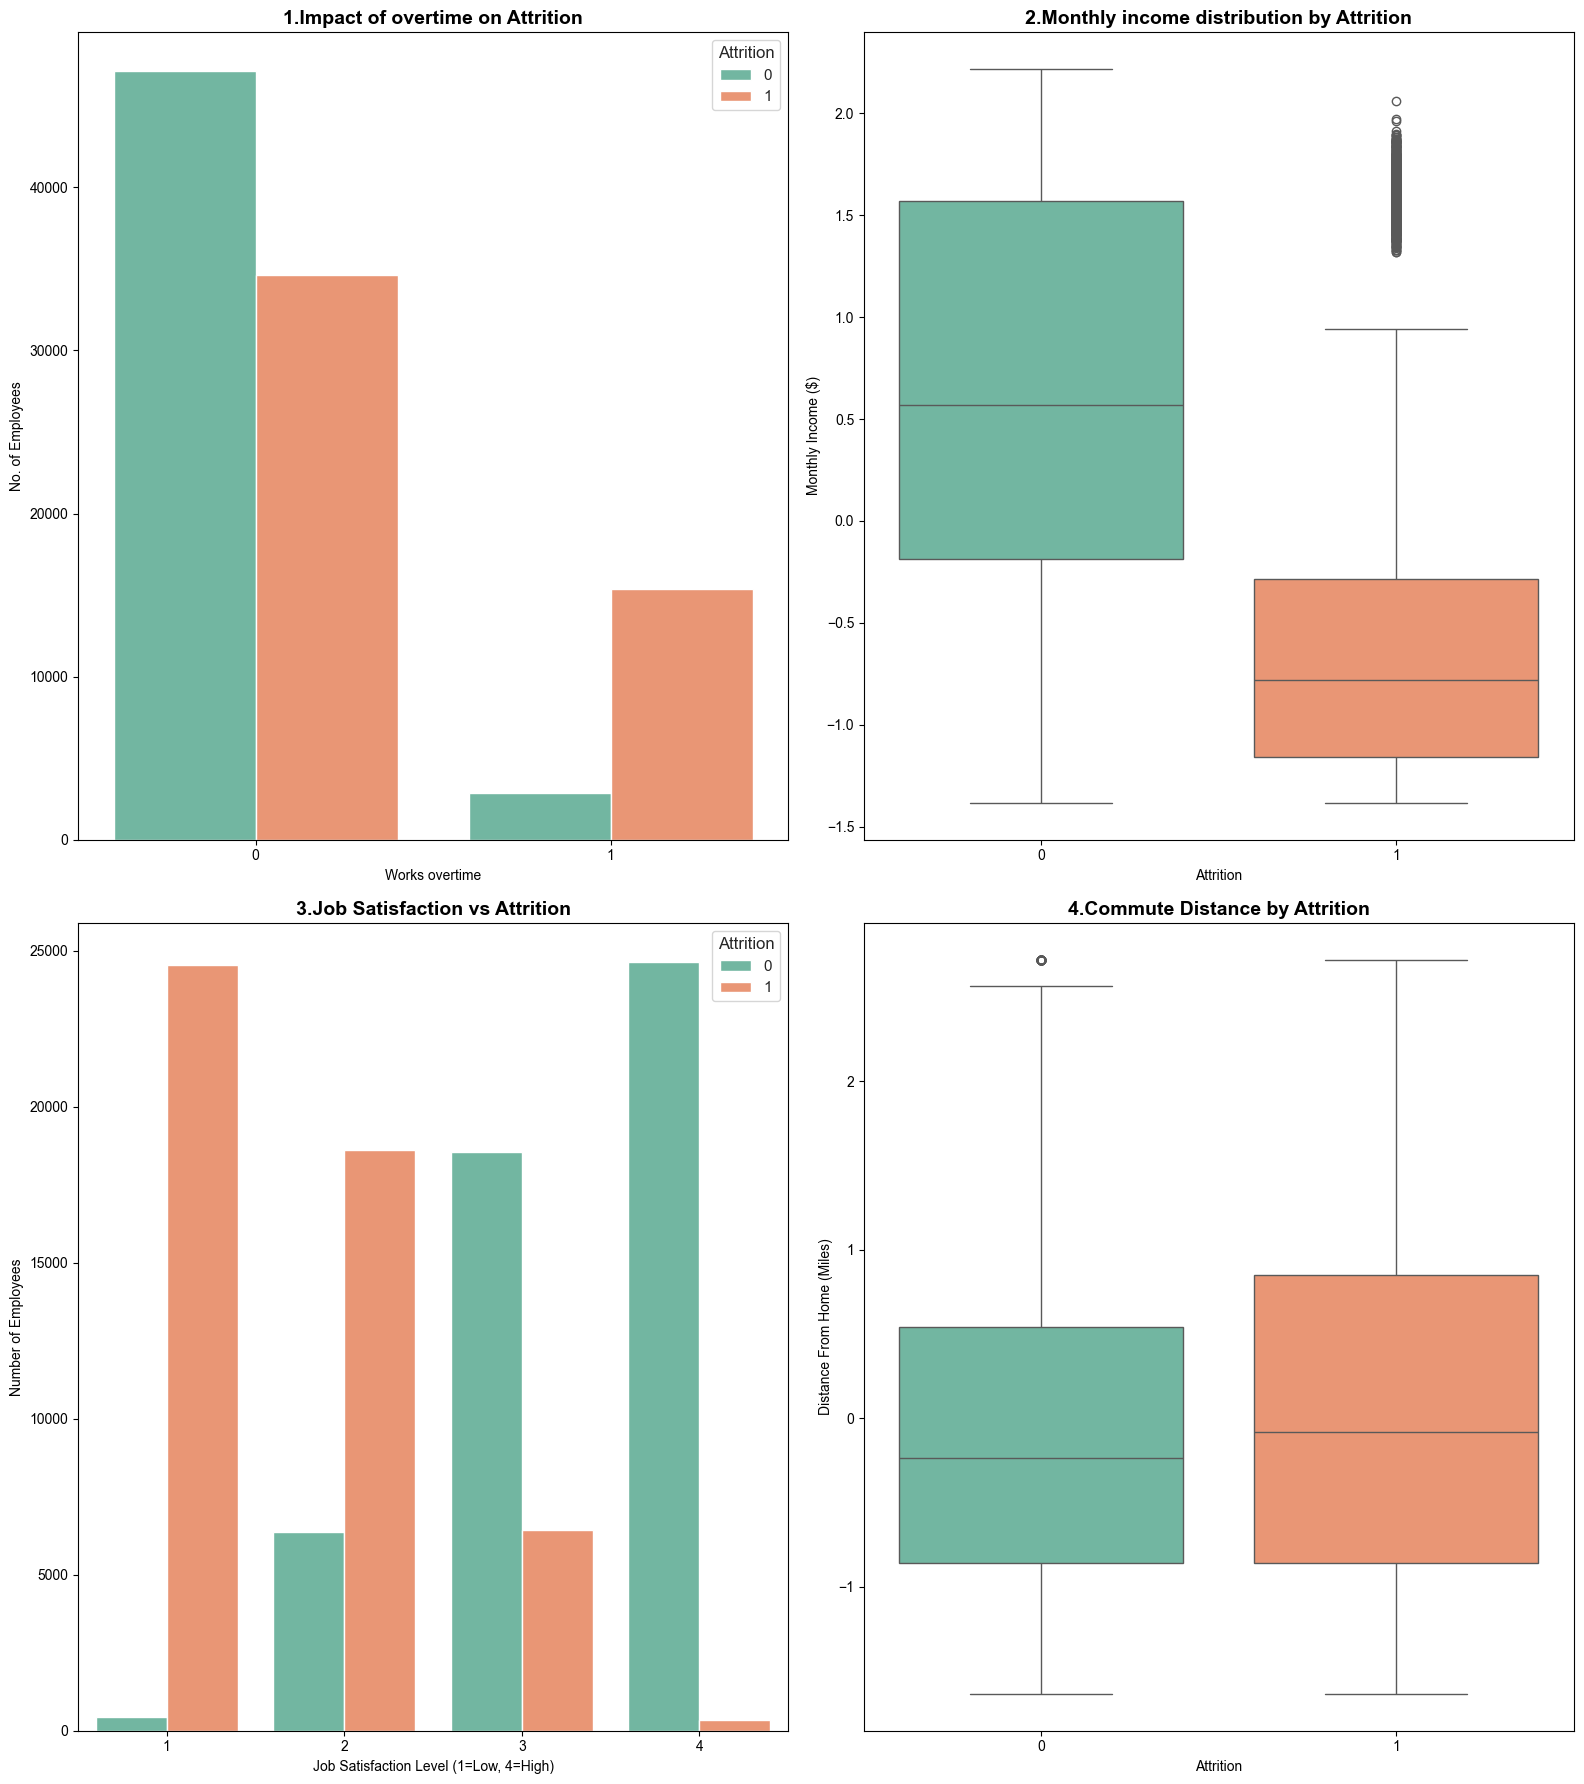

In [18]:
fig,axes=plt.subplots(2,2,figsize=(16,18))
sns.set_theme(style="whitegrid")
sns.countplot(data=df,x='OverTime',hue='Attrition',ax=axes[0,0],palette='Set2')
axes[0,0].set_title('1.Impact of overtime on Attrition', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Works overtime')
axes[0,0].set_ylabel('No. of Employees')
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', ax=axes[0, 1], palette='Set2')
axes[0,1].set_title('2.Monthly income distribution by Attrition', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Attrition')
axes[0,1].set_ylabel('Monthly Income ($)')
sns.countplot(data=df, x='JobSatisfaction', hue='Attrition', ax=axes[1, 0], palette='Set2')
axes[1,0].set_title('3.Job Satisfaction vs Attrition', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Job Satisfaction Level (1=Low, 4=High)')
axes[1,0].set_ylabel('Number of Employees')
sns.boxplot(data=df, x='Attrition', y='DistanceFromHome', ax=axes[1, 1], palette='Set2')
axes[1,1].set_title('4.Commute Distance by Attrition', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Attrition')
axes[1,1].set_ylabel('Distance From Home (Miles)')
plt.tight_layout()
plt.show()

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X=df.drop('Attrition', axis=1)
y=df['Attrition']
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2,stratify=y)
continuous_cols=["Age","MonthlyIncome","YearsAtCompany","DistanceFromHome"]
for col in continuous_cols:
    Q1=X_train[col].quantile(0.25)
    Q3=X_train[col].quantile(0.75)
    IQR=Q3-Q1
    lower_bound=Q1-1.5*IQR
    uppr_bound=Q3+1.5*IQR
    outliers=X_train[(X_train[col]<lower_bound)|(X_train[col]>uppr_bound)].shape[0]
    print(f"Found {outliers} outliers in {col}")

Found 0 outliers in Age
Found 0 outliers in MonthlyIncome
Found 3347 outliers in YearsAtCompany
Found 0 outliers in DistanceFromHome


In [20]:
Q1=X_train['YearsAtCompany'].quantile(0.25)
Q3=X_train['YearsAtCompany'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
mask=(X_train['YearsAtCompany']>=lower_bound)&(X_train['YearsAtCompany']<=upper_bound)
X_train=X_train[mask]
y_train=y_train[mask]
print(f"Outliers removed and X_train shape: {X_train.shape}")
print(f"New y_train shape: {y_train.shape}")

Outliers removed and X_train shape: (76635, 9)
New y_train shape: (76635,)


In [21]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix

In [22]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": LinearSVC(random_state=42, max_iter=10000)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append({"Model": name, "Accuracy": acc})
    print(f"\n{name}")
    print(confusion_matrix(y_test, y_pred))
    print(f"Accuracy: {acc:.4f}")

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Accuracy", ascending=False)

print("\nComparison Table:")
print(results_df.to_string(index=False))


Random Forest
[[9172  827]
 [ 736 9261]]
Accuracy: 0.9218

Gradient Boosting
[[9246  753]
 [ 650 9347]]
Accuracy: 0.9298

SVM
[[9262  737]
 [ 649 9348]]
Accuracy: 0.9307

Comparison Table:
            Model  Accuracy
              SVM  0.930686
Gradient Boosting  0.929836
    Random Forest  0.921834


In [23]:
# Comparison Table
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)
print("\nFinal Model Comparison:")
print(results_df.to_string(index=False))


Final Model Comparison:
            Model  Accuracy
              SVM  0.930686
Gradient Boosting  0.929836
    Random Forest  0.921834


In [25]:
import joblib

# Save final model
final_model = LinearSVC(
    random_state=42,
    max_iter=10000
)

final_model.fit(X_train, y_train)

# Save model
joblib.dump(final_model, "employee_attrition_model.pkl")

# Save scaler
joblib.dump(scaler, "employee_scaler.pkl")

print("Model and scaler saved successfully!")

Model and scaler saved successfully!
